<a href="https://colab.research.google.com/github/rohanyashraj/iai-workshop/blob/main/02_models_as_tools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 · Models as Tools — data, GLM, XGBoost, SHAP

**Agentic AI for Health Actuaries** · IAI Seminar · 25 August 2026 · Hub: `github.com/rohanyashraj/iai-workshop`

> All data in this notebook is **hypothetical** — ABC Health is a fictional entity calibrated to plausible Indian health insurance experience, for teaching only.

**Used in:** Session 1, Parts 3–4.
**You will:** inspect a realistic PMI (health) book, find a leakage trap, fit a Poisson GLM and an XGBoost challenger, referee them with an out-of-time lift chart, explain them with SHAP, run a fairness spot-check — and then wrap it all as **agent-ready tools** (the exact functions the capstone agent calls in notebook 05).

In [1]:
%pip install -q "xgboost==3.2.0" "shap==0.51.0" "statsmodels==0.14.6" "scikit-learn==1.9.0"

/Users/mohithsai/Downloads/Kasyap/IAI_25082026_notebooks/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## §1 · Generate and inspect ABC Health 2024
Self-contained synthetic data — the notebook runs anywhere, no download. Then the three commands you run on **every** dataset before anything else.

In [2]:
print("Hello")

Hello


In [3]:
# --- ABC Health 2024: synthetic hypothetical PMI dataset (self-contained, no download needed) ---
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
N = 50_000

health = pd.DataFrame({
    "policy_id": [f"ABC-PMI-{i:06d}" for i in range(1, N + 1)],
    "member_age_years": rng.integers(18, 76, N),
    "gender": rng.choice(["M", "F"], N, p=[0.55, 0.45]),
    "plan_type": rng.choice(["Individual", "Family Floater"], N, p=[0.55, 0.45]),
    "sum_insured_lakhs": rng.choice([5, 10, 15, 25], N, p=[0.35, 0.35, 0.20, 0.10]),
    "bmi": np.clip(rng.normal(25, 4, N), 16, 42).round(1),
    "city_tier": rng.choice(["Tier1", "Tier2", "Tier3"], N, p=[0.40, 0.35, 0.25]),
    "ncb_pct": rng.choice([0, 10, 20, 30], N, p=[0.30, 0.25, 0.20, 0.25]),
    "prior_claims_3y": rng.choice([0, 1, 2, 3], N, p=[0.70, 0.20, 0.07, 0.03]),
    "room_rent_category": rng.choice(["Standard", "Private", "Suite"], N, p=[0.55, 0.35, 0.10]),
})
# co_pay_pct is a deterministic function of sum_insured_lakhs (higher cover -> lower mandatory
# co-pay) — deliberately EXCLUDED from modelling features below (see §2): a column that is a
# fixed function of another feature smears the signal across two columns instead of one.
copay_map = {5: 20, 10: 15, 15: 10, 25: 5}
health["co_pay_pct"] = health["sum_insured_lakhs"].map(copay_map)

# earned exposure over each member's own observation year (mid-term entries/exits)
health["exposure_years"] = rng.uniform(0.25, 1.0, N).round(3)
# underwriting cohort month — used for the out-of-time split (each cohort observed over its full policy year)
health["inception_month"] = rng.integers(1, 13, N)

# True frequency model (the "world"): base ~2% with realistic loadings, landing near 6% portfolio-wide
lin = (np.log(0.0195)
       + 0.018 * health["member_age_years"]
       + 0.020 * health["sum_insured_lakhs"]
       + 0.030 * (health["bmi"] - 25)
       - 0.006 * health["ncb_pct"]
       + 0.150 * health["prior_claims_3y"]
       + np.where(health["city_tier"] == "Tier1", 0.10, np.where(health["city_tier"] == "Tier3", -0.12, 0.0))
       + np.where(health["plan_type"] == "Family Floater", 0.05, 0.0))
health["claim_count"] = rng.poisson(np.exp(lin) * health["exposure_years"])
# severity: Gamma, mean ~85k, only where claims exist
sev = rng.gamma(shape=2.2, scale=38_600, size=N)
health["claim_amount_inr"] = (health["claim_count"] * sev).round(0)

print("Shape:", health.shape)
freq = health.claim_count.sum() / health.exposure_years.sum()
sev_mean = health.loc[health.claim_count > 0, "claim_amount_inr"].sum() / max(health.claim_count.sum(), 1)
print(f"Portfolio frequency: {freq:.3f} per member-year | mean severity: INR {sev_mean:,.0f}")
health.head()


Shape: (50000, 15)
Portfolio frequency: 0.062 per member-year | mean severity: INR 84,321


,policy_id,member_age_years,gender,plan_type,sum_insured_lakhs,bmi,city_tier,ncb_pct,prior_claims_3y,room_rent_category,co_pay_pct,exposure_years,inception_month,claim_count,claim_amount_inr
0,ABC-PMI-000001,23,F,Family Floater,10,32.0,Tier1,10,0,Private,15,0.883,5,0,0.0
1,ABC-PMI-000002,62,F,Individual,10,21.7,Tier3,10,0,Private,15,0.724,10,0,0.0
2,ABC-PMI-000003,55,F,Family Floater,10,26.3,Tier2,30,1,Private,15,0.315,11,1,3250.0
3,ABC-PMI-000004,43,M,Family Floater,10,28.0,Tier2,20,1,Standard,15,0.620,12,0,0.0
4,ABC-PMI-000005,43,M,Family Floater,15,28.7,Tier1,20,2,Standard,10,0.299,3,0,0.0


In [4]:
health.info()
health.describe().T.head(12)


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   policy_id           50000 non-null  str    
 1   member_age_years    50000 non-null  int64  
 2   gender              50000 non-null  str    
 3   plan_type           50000 non-null  str    
 4   sum_insured_lakhs   50000 non-null  int64  
 5   bmi                 50000 non-null  float64
 6   city_tier           50000 non-null  str    
 7   ncb_pct             50000 non-null  int64  
 8   prior_claims_3y     50000 non-null  int64  
 9   room_rent_category  50000 non-null  str    
 10  co_pay_pct          50000 non-null  int64  
 11  exposure_years      50000 non-null  float64
 12  inception_month     50000 non-null  int64  
 13  claim_count         50000 non-null  int64  
 14  claim_amount_inr    50000 non-null  float64
dtypes: float64(3), int64(7), str(5)
memory usage: 5.7 MB


,count,mean,std,min,25%,50%,75%,max
member_age_years,50000.0,46.467040,16.755639,18.00,32.000,47.000,61.000,75.0
sum_insured_lakhs,50000.0,10.756800,5.994412,5.00,5.000,10.000,15.000,25.0
bmi,50000.0,25.033396,3.949000,16.00,22.300,25.000,27.700,42.0
ncb_pct,50000.0,13.983800,11.561402,0.00,0.000,10.000,20.000,30.0
prior_claims_3y,50000.0,0.428920,0.754426,0.00,0.000,0.000,1.000,3.0
co_pay_pct,50000.0,14.747900,4.881027,5.00,10.000,15.000,20.000,20.0
exposure_years,50000.0,0.622862,0.216381,0.25,0.436,0.622,0.811,1.0
inception_month,50000.0,6.490780,3.458270,1.00,3.000,7.000,9.000,12.0
claim_count,50000.0,0.038420,0.197243,0.00,0.000,0.000,0.000,2.0
claim_amount_inr,50000.0,3239.609760,20307.302971,0.00,0.000,0.000,0.000,594254.0


### Exposure-weighted frequency by member age
Sum claims and exposure **separately**, then divide — never `groupby().mean()` on partial-year policies.


Matplotlib is building the font cache; this may take a moment.


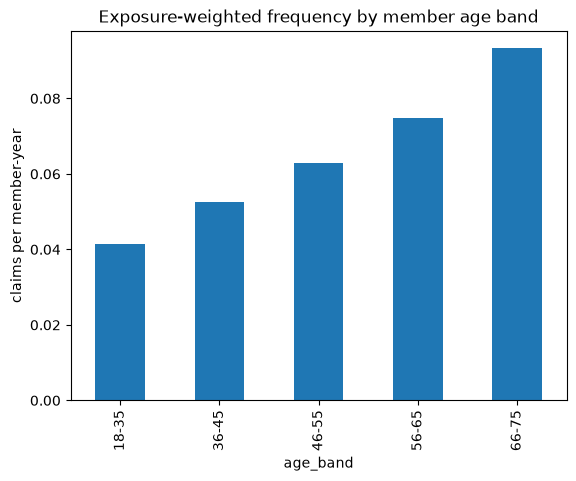

In [5]:
import matplotlib
bins, labels = [17, 35, 45, 55, 65, 76], ["18-35", "36-45", "46-55", "56-65", "66-75"]
health["age_band"] = pd.cut(health.member_age_years, bins=bins, labels=labels)
freq_by_band = (health.groupby("age_band", observed=True)
                     .apply(lambda g: g.claim_count.sum() / g.exposure_years.sum(),
                            include_groups=False))
ax = freq_by_band.plot(kind="bar", title="Exposure-weighted frequency by member age band")
ax.set_ylabel("claims per member-year");


## §2 · EXERCISE — find the column that breaks the model (3 minutes)
We predict whether a policy claimed at all. The quick model below scores a **perfect AUC**. Nothing is that good. One column gives the answer away — find it. *(Hint: it's measured in rupees.)*

**Why this matters for agents:** a human might smell a perfect AUC; an agent will happily fit, report and ship it — unless the tool it calls refuses leaky features.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

y_bin = (health.claim_count > 0).astype(int)
X_leaky = health.select_dtypes("number").drop(columns=["claim_count"])   # numeric kitchen sink
Xtr, Xte, ytr, yte = train_test_split(X_leaky, y_bin, random_state=0)
auc = roc_auc_score(yte, LogisticRegression(max_iter=2000).fit(Xtr, ytr).predict_proba(Xte)[:, 1])
print(f"Test AUC = {auc:.3f}   <-- alarm bells")
print("\nColumns offered to the model:", list(X_leaky.columns))


Test AUC = 1.000   <-- alarm bells

Columns offered to the model: ['member_age_years', 'sum_insured_lakhs', 'bmi', 'ncb_pct', 'prior_claims_3y', 'co_pay_pct', 'exposure_years', 'inception_month', 'claim_amount_inr']


In [7]:
# REVEAL — run after you've guessed
# claim_amount_inr is non-zero exactly when the target is 1: pure target leakage.
# Rule: if a feature is knowable only AFTER the event you're predicting, it's leakage. Drop it.
FEATURES = ["member_age_years", "sum_insured_lakhs", "bmi",
            "ncb_pct", "prior_claims_3y"]          # numeric, lawful, pre-event
CATEGORICAL = ["plan_type", "city_tier"]
# Note: co_pay_pct is deliberately EXCLUDED — it is a deterministic function of sum_insured_lakhs
# (multicollinearity would smear the sum-insured signal across two columns). Exercise: add it back
# to the GLM and watch the sum_insured_lakhs coefficient lose significance.
print("Governed feature list (lives INSIDE the tools from here on):", FEATURES + CATEGORICAL)


Governed feature list (lives INSIDE the tools from here on): ['member_age_years', 'sum_insured_lakhs', 'bmi', 'ncb_pct', 'prior_claims_3y', 'plan_type', 'city_tier']


## §3 · Tool #1 — the Poisson GLM (frequency)
Same GLM you know from SAS/R: log link, `log(earned exposure)` offset, coefficients = rating relativities.

In [8]:
import statsmodels.api as sm

def design_matrix(df):
    X = pd.get_dummies(df[FEATURES + CATEGORICAL], drop_first=True).astype(float)
    return sm.add_constant(X, has_constant="add")

X = design_matrix(health)
y = health["claim_count"]
offset = np.log(health["exposure_years"])

glm_freq = sm.GLM(y, X, family=sm.families.Poisson(), offset=offset).fit()
print(glm_freq.summary().tables[1])

                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -4.4357      0.177    -25.092      0.000      -4.782      -4.089
member_age_years         0.0180      0.001     12.853      0.000       0.015       0.021
sum_insured_lakhs        0.0223      0.004      6.273      0.000       0.015       0.029
bmi                      0.0284      0.006      4.914      0.000       0.017       0.040
ncb_pct                 -0.0060      0.002     -3.028      0.002      -0.010      -0.002
prior_claims_3y          0.1432      0.027      5.227      0.000       0.090       0.197
plan_type_Individual    -0.1398      0.046     -3.062      0.002      -0.229      -0.050
city_tier_Tier2         -0.1192      0.052     -2.303      0.021      -0.221      -0.018
city_tier_Tier3         -0.2831      0.060     -4.688      0.000      -0.402      -0.165


## §4 · Tool #2 — the XGBoost challenger + out-of-time split
Actuaries split by **time**, never at random: train on months 1–6, validate 7–9, test 10–12. Note `objective='count:poisson'` — we model counts, not squared error.

In [12]:
from xgboost import XGBRegressor

train = health[health.inception_month <= 6]
val   = health[health.inception_month.between(7, 9)]
test  = health[health.inception_month >= 10]

def xy(df):
    X = pd.get_dummies(df[FEATURES + CATEGORICAL], drop_first=True).astype(float)
    return X, df.claim_count, df.exposure_years

Xtr, ytr, etr = xy(train); Xva, yva, eva = xy(val); Xte, yte, ete = xy(test)
Xva = Xva.reindex(columns=Xtr.columns, fill_value=0)
Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)

xgb_freq = XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.05,
                        reg_lambda=1.0, objective="count:poisson", random_state=42)
# Train on FREQUENCY (count / earned exposure), weighted by exposure —
# the tree-model equivalent of the GLM's log-exposure offset.
xgb_freq.fit(Xtr, ytr / etr, sample_weight=etr, verbose=False)

glm_oot = sm.GLM(ytr, sm.add_constant(Xtr, has_constant="add"),
                 family=sm.families.Poisson(), offset=np.log(etr)).fit()
print("Both models fitted on H1, ready to score Q4 (never seen).")

Both models fitted on H1, ready to score Q4 (never seen).


## §5 · The referee — exposure-weighted lift table on Q4

         GLM  XGBoost
band                 
1     0.0301   0.0333
2     0.0454   0.0531
3     0.0435   0.0527
4     0.0658   0.0610
5     0.1002   0.0927

Top/bottom band ratio — GLM: 3.3x | XGB: 2.8x


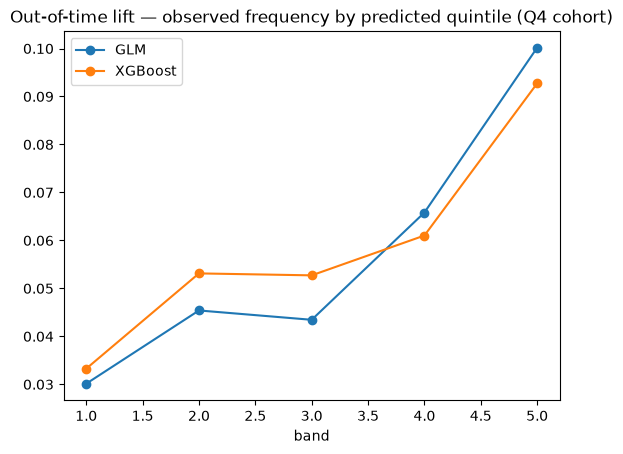

In [ ]:
def lift_table(y_actual, y_pred, exposure, n=5):
    # quintiles on a 5,000-policy book; use deciles (n=10) on larger books
    df = pd.DataFrame({"pred": y_pred, "actual": y_actual, "expo": exposure})
    df["band"] = pd.qcut(df.pred.rank(method="first"), n, labels=False) + 1
    return (df.groupby("band")
              .apply(lambda g: g.actual.sum() / g.expo.sum(), include_groups=False)
              .rename("observed_freq"))

glm_pred = glm_oot.predict(sm.add_constant(Xte, has_constant="add"), offset=np.log(ete))
xgb_pred = xgb_freq.predict(Xte) * ete   # model predicts a rate; x exposure = expected counts

lift = pd.DataFrame({"GLM": lift_table(yte, glm_pred, ete),
                     "XGBoost": lift_table(yte, xgb_pred, ete)})
print(lift.round(4))
lift.plot(marker="o", title="Out-of-time lift — observed frequency by predicted quintile (Q4 cohort)")
print(f"\nTop/bottom band ratio — GLM: {lift.GLM.iloc[-1]/lift.GLM.iloc[0]:.1f}x | "
      f"XGB: {lift.XGBoost.iloc[-1]/lift.XGBoost.iloc[0]:.1f}x")

**Read it like a pricing committee:** on a 5,000-policy book the GLM holds its own on calibration; the tree usually wins segmentation at the extremes — where pricing leakage hides. They answer different questions, which is why the agent gets *both*.

## §6 · Tool #3 — SHAP (global + local)

d:\Kasyap\Agentic AI Session\IAI\Notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


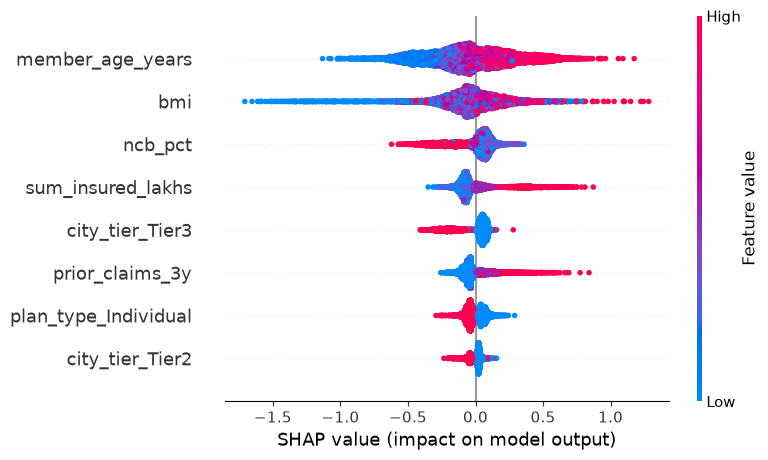

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_freq)
sv = explainer(Xte)
shap.summary_plot(sv, Xte, max_display=8)     # GLOBAL: has the tree learned anything perverse?

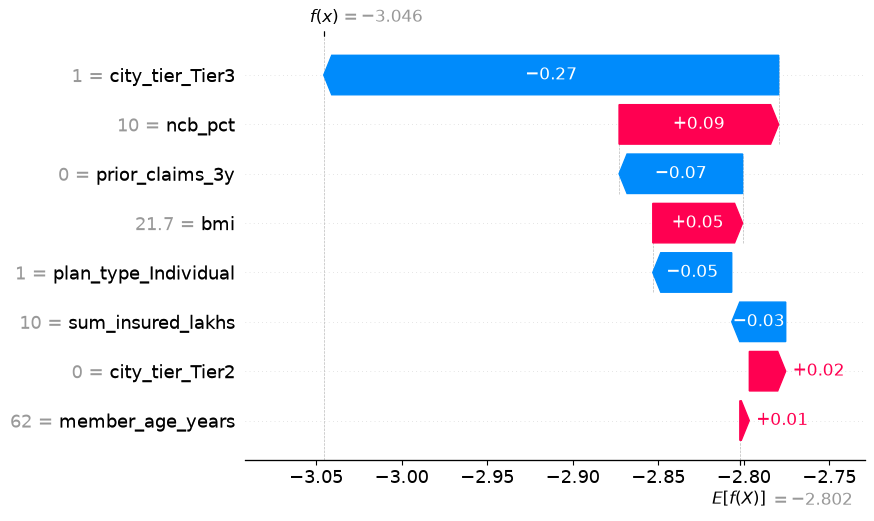

Every push traces to a data column — this is the customer letter and the regulator's answer.


In [ ]:
i = 0                                          # LOCAL: why did THIS policy get that score?
shap.plots.waterfall(sv[i], max_display=8)
print("Every push traces to a data column — this is the customer letter and the regulator's answer.")

## §7 · Fairness spot-check — calibration within subgroup
Predicted vs observed by gender × age band, **even though gender is not a model feature** — that's the proxy-discrimination test from the slides.

In [ ]:
audit = test.copy()
audit["pred_count"] = xgb_pred
audit["age_band"] = pd.cut(audit.member_age_years, [18, 35, 60, 80])

def cell_rates(g):
    return pd.Series({"observed": g.claim_count.sum() / g.exposure_years.sum(),
                      "predicted": g.pred_count.sum() / g.exposure_years.sum()})

report = (audit.groupby(["gender", "age_band"], observed=True)
               .apply(cell_rates, include_groups=False).round(4))
print(report)
gap = (report.observed - report.predicted).abs().max()
print(f"\nLargest |observed - predicted| gap: {gap:.4f} "
      f"{'✓ within tolerance (0.03)' if gap < 0.03 else '⚠ investigate before shipping'}")
# Exposure-weighted within-cell calibration — the fairness definition we chose and can defend.


                 observed  predicted
gender age_band                     
F      (18, 35]    0.0340     0.0437
       (35, 60]    0.0605     0.0593
       (60, 80]    0.0809     0.0834
M      (18, 35]    0.0371     0.0450
       (35, 60]    0.0661     0.0595
       (60, 80]    0.1000     0.0856

Largest |observed - predicted| gap: 0.0144 ✓ within tolerance (0.03)


## §8 · Wrap it all as agent-ready tools
This is the whole point of the morning: every artefact above becomes a **typed function with a docstring** — the exact tools the capstone agent calls in notebook 05. Judgement (feature list, split policy, fairness tolerance) is encoded **once, inside the tool**.

**Two shapes of tool, and the difference is the whole lesson.** `fit_glm_tool` and the three
below it take no arguments — they re-run a step of *this* pipeline and hand back a table.
Useful, but an agent cannot ask them anything about a particular member.

`predict_frequency` takes the seven governed features as typed arguments, answers one question
about one member, refuses inputs the GLM was never fitted on, and returns the model string
beside the number. That is the shape every tool in notebooks 04 and 05 uses, and it is the
shape on the Tool Card from Part 3. **Write the second kind.**

> Look closely at `drop_first=False` and the comment above it. Encoding a single row is where
> tools quietly go wrong: `drop_first=True` would delete this member's own category and price
> them as the reference class — no error, no warning, just a wrong number. The refusal check
> two lines earlier is what makes an all-zero encoding safe to trust.


In [ ]:
def fit_glm_tool() -> dict:
    """Fit the governed Poisson frequency GLM on ABC Health 2024 (H1 train).
    Returns coefficient table and train window. Feature list is fixed inside the tool."""
    return {"model": "Poisson GLM", "train_window": "2024 months 1-6",
            "coefficients": glm_oot.params.round(4).to_dict()}

def fit_xgb_tool() -> dict:
    """Fit the governed XGBoost frequency challenger. Hyperparameters and features fixed inside."""
    return {"model": "XGBoost count:poisson", "n_estimators": 500, "max_depth": 4}

def lift_table_tool() -> dict:
    """Out-of-time (Q4 2024) decile lift for GLM vs XGBoost. The referee."""
    return lift.round(4).to_dict()

def shap_top_features_tool() -> dict:
    """Global mean |SHAP| ranking for the XGBoost model."""
    mean_abs = pd.Series(np.abs(sv.values).mean(axis=0), index=Xte.columns)
    return mean_abs.sort_values(ascending=False).head(6).round(4).to_dict()

def predict_frequency(member_age_years: int, sum_insured_lakhs: float, bmi: float,
                      ncb_pct: float, prior_claims_3y: int,
                      plan_type: str, city_tier: str) -> dict:
    """Expected annual claim frequency, per member-year, for ONE member, from the governed
    Poisson GLM fitted on H1 2024.

    The seven arguments ARE the governed feature list - FEATURES + CATEGORICAL. Nothing else
    reaches the model, so nothing else can leak into a price. claim_amount_inr is not an
    argument and never will be.

    Args:
        member_age_years:  age at renewal, 18-75
        sum_insured_lakhs: sum insured in INR lakhs
        bmi:               body mass index
        ncb_pct:           no-claim bonus percentage currently earned
        prior_claims_3y:   claims in the last three policy years
        plan_type:         'Individual' or 'Family Floater'
        city_tier:         'Tier1', 'Tier2' or 'Tier3' - ABC Health's rating tier, not a postcode

    Returns the frequency, the model that produced it, and the training window, so that in
    March somebody can ask which model priced this and get an answer.

    Do NOT use for reserving: this is a pricing frequency on an earned-exposure basis and it
    ignores IBNR entirely.

    Refuses rather than extrapolates. An age, a plan or a tier the GLM never saw raises,
    because a silent extrapolation is worse than an error somebody has to read.
    """
    if not 18 <= member_age_years <= 75:
        raise ValueError(f"age {member_age_years} is outside the fitted range 18-75")
    for col, val in (("plan_type", plan_type), ("city_tier", city_tier)):
        levels = sorted(health[col].unique())
        if val not in levels:
            raise ValueError(f"{col}={val!r} was never fitted. Known levels: {levels}")

    row = pd.DataFrame([{ "member_age_years": member_age_years,
                          "sum_insured_lakhs": sum_insured_lakhs, "bmi": bmi,
                          "ncb_pct": ncb_pct, "prior_claims_3y": prior_claims_3y,
                          "plan_type": plan_type, "city_tier": city_tier }])
    # drop_first=False on purpose. On a single row, drop_first would delete the member's OWN
    # level and silently encode them as the reference class - a wrong price with no error.
    # Reindexing onto the fitted coefficient names does the dropping correctly instead: a
    # reference-level member legitimately gets all-zero dummies, and we have already refused
    # any level the GLM never saw.
    dummies = pd.get_dummies(row[FEATURES + CATEGORICAL], drop_first=False).astype(float)
    X = dummies.reindex(columns=glm_oot.params.index, fill_value=0.0)
    X["const"] = 1.0
    encoded = [c for c in dummies.columns if c in glm_oot.params.index and dummies[c].iloc[0] == 1.0
               and c not in FEATURES]
    # No offset: the GLM's offset is log(exposure), so offset=0 is exactly one member-year.
    return {"frequency_per_member_year": round(float(glm_oot.predict(X).iloc[0]), 5),
            "model": "Poisson GLM", "train_window": "2024 months 1-6",
            "basis": "earned exposure, per member-year, excludes IBNR",
            "levels_encoded": encoded or ["both categoricals at reference level"]}


demo = predict_frequency(member_age_years=45, sum_insured_lakhs=5.0, bmi=27.0,
                         ncb_pct=20.0, prior_claims_3y=1,
                         plan_type="Individual", city_tier="Tier2")
print("predict_frequency(...) ->", demo)
try:
    predict_frequency(45, 5.0, 27.0, 20.0, 1, "Individual", "Tier9")
except ValueError as e:
    print("refused  ->", e)


print(lift_table_tool())
print(shap_top_features_tool())
print("\nFour governed tools, ready for an agent. See you in notebook 05.")


{'GLM': {1: 0.0301, 2: 0.0454, 3: 0.0435, 4: 0.0658, 5: 0.1002}, 'XGBoost': {1: 0.0333, 2: 0.0531, 3: 0.0527, 4: 0.061, 5: 0.0927}}
{'member_age_years': 0.2467000037431717, 'bmi': 0.16290000081062317, 'ncb_pct': 0.10840000212192535, 'sum_insured_lakhs': 0.10580000281333923, 'city_tier_Tier3': 0.08959999680519104, 'prior_claims_3y': 0.07810000330209732}

Four governed tools, ready for an agent. See you in notebook 05.
